# HW12 — временные ряды: temporal split, лаговые признаки и GRU

Этот ноутбук решает домашнюю работу по прогнозированию временного ряда:

- корректно сортирует данные по времени;
- делает `train / validation / test` **по времени**;
- строит лаговые, rolling- и календарные признаки;
- сравнивает `naive-last`, `moving-average`, `Ridge` и `GRU`;
- сохраняет артефакты эксперимента в `artifacts/`.

## 0. Импорты, seed и устройство

In [1]:
from __future__ import annotations

import copy
import json
import math
import random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)



HW_DIR = Path(".")
ARTIFACTS_DIR = HW_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("HW_DIR:", HW_DIR)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)

HW_DIR: .
ARTIFACTS_DIR: artifacts


## 1. Данные и первичный анализ

In [3]:
def find_dataset_path() -> Path:
    candidates = [
        HW_DIR / "S12-hw-dataset.csv",
        HW_DIR / "homeworks" / "HW12" / "S12-hw-dataset.csv",
        Path.cwd() / "S12-hw-dataset.csv",
        Path.cwd() / "homeworks" / "HW12" / "S12-hw-dataset.csv",
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "Не найден S12-hw-dataset.csv. "
        "Положите файл рядом с репозиторием или в homeworks/HW12/."
    )


DATA_PATH = find_dataset_path()
df_raw = pd.read_csv(DATA_PATH)

print("Loaded:", DATA_PATH)
print("Shape:", df_raw.shape)
display(df_raw.head())

Loaded: S12-hw-dataset.csv
Shape: (4320, 2)


,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [4]:
required_cols = {"date", "target"}
missing_required = required_cols - set(df_raw.columns)
if missing_required:
    raise ValueError(f"В датасете не хватает обязательных колонок: {missing_required}")

df = df_raw.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date", "target"]).copy()
df = df.sort_values("date").drop_duplicates(subset=["date"], keep="first").reset_index(drop=True)

print(f"Число наблюдений: {len(df)}")
print(f"Диапазон дат: {df['date'].min().date()} — {df['date'].max().date()}")
print("Пропуски по колонкам:")
display(df.isna().sum().to_frame("missing_count"))
display(df[["date", "target"]].describe(include="all").T)

Число наблюдений: 4320
Диапазон дат: 2025-01-01 — 2025-06-29
Пропуски по колонкам:


,missing_count
date,0
target,0


,count,mean,min,25%,50%,75%,max,std
date,4320,2025-03-31 23:29:59.999999744,2025-01-01 00:00:00,2025-02-14 23:45:00,2025-03-31 23:30:00,2025-05-15 23:15:00,2025-06-29 23:00:00,NaN
target,4320.0,135.60584,69.1,120.5375,135.835,150.625,210.1,21.384633


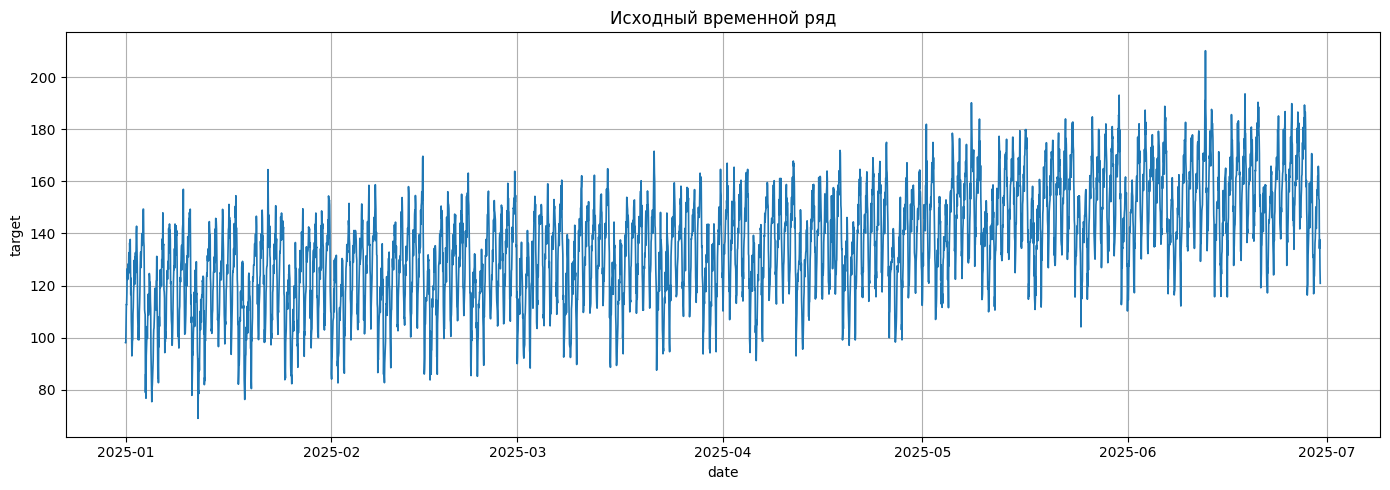

In [5]:
fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], linewidth=1.2)
ax.set_title("Исходный временной ряд")
ax.set_xlabel("date")
ax.set_ylabel("target")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "raw_series.png", dpi=150, bbox_inches="tight")
plt.show()

Краткий комментарий к ряду стоит писать после просмотра графика: обычно здесь ищут тренд, сезонность по неделе/месяцу, скачки и возможную нестационарность.  
Если в данных есть пропуски, в этом ноутбуке они удаляются только для обязательных полей `date` и `target`, чтобы не вносить дополнительную утечку через интерполяцию.

## 2. Корректный temporal split

In [6]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15


SPLIT_CFG = SplitConfig()


def temporal_split(df_in: pd.DataFrame, cfg: SplitConfig = SPLIT_CFG):
    n = len(df_in)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))
    train_df = df_in.iloc[:train_end].copy()
    val_df = df_in.iloc[train_end:val_end].copy()
    test_df = df_in.iloc[val_end:].copy()
    return train_df, val_df, test_df, train_end, val_end


def split_summary_text(train_df, val_df, test_df, train_end, val_end) -> str:
    return (
        f"train={len(train_df)} rows ({train_df['date'].min().date()}..{train_df['date'].max().date()}), "
        f"val={len(val_df)} rows ({val_df['date'].min().date()}..{val_df['date'].max().date()}), "
        f"test={len(test_df)} rows ({test_df['date'].min().date()}..{test_df['date'].max().date()}), "
        f"boundaries=[{train_end}, {val_end}]"
    )


train_raw, val_raw, test_raw, train_end_raw, val_end_raw = temporal_split(df)
split_summary = split_summary_text(train_raw, val_raw, test_raw, train_end_raw, val_end_raw)

print(split_summary)
display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train_raw), len(val_raw), len(test_raw)],
    "start": [train_raw["date"].min(), val_raw["date"].min(), test_raw["date"].min()],
    "end": [train_raw["date"].max(), val_raw["date"].max(), test_raw["date"].max()],
}))

train=3024 rows (2025-01-01..2025-05-06), val=648 rows (2025-05-07..2025-06-02), test=648 rows (2025-06-03..2025-06-29), boundaries=[3024, 3672]


,split,rows,start,end
0,train,3024,2025-01-01,2025-05-06 23:00:00
1,validation,648,2025-05-07,2025-06-02 23:00:00
2,test,648,2025-06-03,2025-06-29 23:00:00


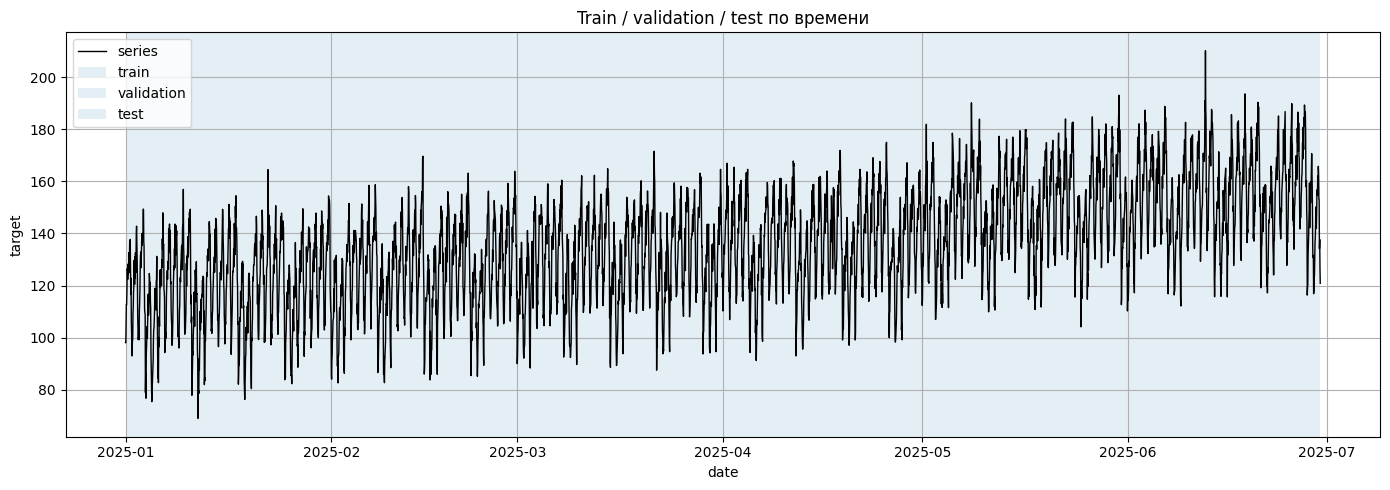

In [7]:
fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], color="black", linewidth=1.0, label="series")

for part, color, label in [
    (train_raw, "tab:blue", "train"),
    (val_raw, "tab:orange", "validation"),
    (test_raw, "tab:green", "test"),
]:
    ax.axvspan(part["date"].min(), part["date"].max(), alpha=0.12, label=label)

ax.set_title("Train / validation / test по времени")
ax.set_xlabel("date")
ax.set_ylabel("target")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "series_split.png", dpi=150, bbox_inches="tight")
plt.show()

`random split` здесь некорректен, потому что он нарушает причинность: в train могут попасть наблюдения из будущего относительно validation/test.  
Для временного ряда нужно имитировать реальный сценарий, где модель учится на прошлом и проверяется на будущем.

## 3. Признаки для baseline-моделей

In [8]:
def make_feature_frame(df_in: pd.DataFrame) -> pd.DataFrame:
    out = df_in.sort_values("date").reset_index(drop=True).copy()
    out["lag_1"] = out["target"].shift(1)
    out["lag_7"] = out["target"].shift(7)
    out["lag_14"] = out["target"].shift(14)
    past_target = out["target"].shift(1)
    out["rolling_mean_7"] = past_target.rolling(7).mean()
    out["rolling_std_7"] = past_target.rolling(7).std(ddof=0)
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month
    out["dayofmonth"] = out["date"].dt.day
    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)
    return out


df_feat = make_feature_frame(df).dropna().reset_index(drop=True)
train_df, val_df, test_df, train_end, val_end = temporal_split(df_feat)
split_summary = split_summary_text(train_df, val_df, test_df, train_end, val_end)

print("After feature engineering:", df_feat.shape)
print(split_summary)

feature_cols = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "dayofweek",
]
target_col = "target"

display(df_feat[["date", "target"] + feature_cols].head(10))

After feature engineering: (4306, 11)
train=3014 rows (2025-01-01..2025-05-07), val=646 rows (2025-05-07..2025-06-03), test=646 rows (2025-06-03..2025-06-29), boundaries=[3014, 3660]


,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,dayofweek
0,2025-01-01 14:00:00,128.87,125.04,126.01,98.14,126.445714,3.032636,2
1,2025-01-01 15:00:00,136.40,128.87,122.38,98.07,126.854286,3.137264,2
2,2025-01-01 16:00:00,133.85,136.40,128.28,104.70,128.857143,3.998542,2
3,2025-01-01 17:00:00,137.71,133.85,124.43,112.81,129.652857,4.343826,2
4,2025-01-01 18:00:00,126.32,137.71,126.35,112.62,131.550000,4.543866,2
5,2025-01-01 19:00:00,116.59,126.32,132.63,117.29,131.545714,4.548780,2
6,2025-01-01 20:00:00,122.83,116.59,125.04,126.50,129.254286,6.872128,2
7,2025-01-01 21:00:00,106.54,122.83,128.87,126.01,128.938571,7.105295,2
8,2025-01-01 22:00:00,101.72,106.54,136.40,122.38,125.748571,10.582027,2
9,2025-01-01 23:00:00,93.04,101.72,133.85,128.28,120.794286,12.397925,2


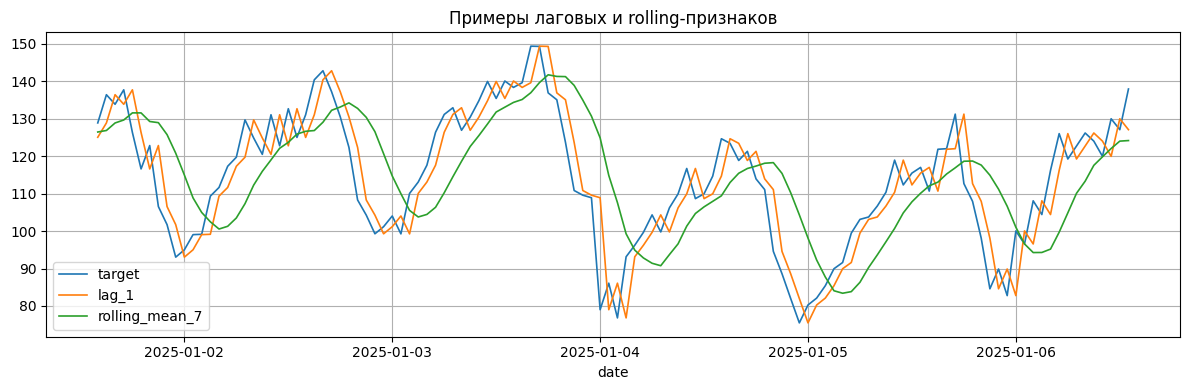

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
sample_cols = ["target", "lag_1", "rolling_mean_7"]
for col in sample_cols:
    ax.plot(df_feat["date"].iloc[:120], df_feat[col].iloc[:120], label=col, linewidth=1.2)
ax.set_title("Примеры лаговых и rolling-признаков")
ax.set_xlabel("date")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_examples.png", dpi=150, bbox_inches="tight")
plt.show()

### Метрики

In [10]:
def regression_metrics(y_true, y_pred) -> dict:
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    smape = np.mean(2.0 * np.abs(y_true - y_pred) / np.clip(np.abs(y_true) + np.abs(y_pred), 1e-8, None)) * 100
    return {"mae": mae, "rmse": rmse, "mape": mape, "smape": smape}

## 4. Baseline B1 — naive last value

In [11]:
def evaluate_baseline(split_df: pd.DataFrame, prediction: np.ndarray) -> dict:
    metrics = regression_metrics(split_df["target"].to_numpy(), prediction)
    return metrics


b1_val_pred = val_df["lag_1"].to_numpy()
b1_test_pred = test_df["lag_1"].to_numpy()

b1_val_metrics = evaluate_baseline(val_df, b1_val_pred)
b1_test_metrics = evaluate_baseline(test_df, b1_test_pred)

display(pd.DataFrame([{"split": "validation", **b1_val_metrics}, {"split": "test", **b1_test_metrics}]))

,split,mae,rmse,mape,smape
0,validation,6.443406,8.203532,4.394594,4.360592
1,test,6.338019,8.059906,4.143508,4.118023


## 5. Baseline B2 — moving average

In [12]:
b2_val_pred = val_df["rolling_mean_7"].to_numpy()
b2_test_pred = test_df["rolling_mean_7"].to_numpy()

b2_val_metrics = evaluate_baseline(val_df, b2_val_pred)
b2_test_metrics = evaluate_baseline(test_df, b2_test_pred)

display(pd.DataFrame([{"split": "validation", **b2_val_metrics}, {"split": "test", **b2_test_metrics}]))

,split,mae,rmse,mape,smape
0,validation,12.723717,15.236326,8.828779,8.626417
1,test,12.725250,15.226179,8.534403,8.335380


## 6. Baseline B3 — Ridge на лаговых и календарных признаках

In [13]:
ridge_features = feature_cols

X_train = train_df[ridge_features]
y_train = train_df[target_col]
X_val = val_df[ridge_features]
y_val = val_df[target_col]
X_test = test_df[ridge_features]
y_test = test_df[target_col]

ridge_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0)),
    ]
)
ridge_model.fit(X_train, y_train)

b3_val_pred = ridge_model.predict(X_val)
b3_test_pred = ridge_model.predict(X_test)

b3_val_metrics = regression_metrics(y_val, b3_val_pred)
b3_test_metrics = regression_metrics(y_test, b3_test_pred)

display(pd.DataFrame([{"split": "validation", **b3_val_metrics}, {"split": "test", **b3_test_metrics}]))

,split,mae,rmse,mape,smape
0,validation,7.171741,8.723752,4.782421,4.883477
1,test,7.318698,9.028900,4.685315,4.810716


## 7. GRU: оконное представление и DataLoader

In [14]:
WINDOW_SIZE = 28
BATCH_SIZE = 64


class SequenceDataset(Dataset):
    def __init__(self, values_scaled: np.ndarray, target_indices: np.ndarray, window_size: int):
        self.values = torch.tensor(values_scaled, dtype=torch.float32)
        self.target_indices = np.asarray(target_indices, dtype=int)
        self.window_size = int(window_size)

    def __len__(self) -> int:
        return len(self.target_indices)

    def __getitem__(self, idx: int):
        t = self.target_indices[idx]
        x = self.values[t - self.window_size : t].unsqueeze(-1)  # (seq_len, 1)
        y = self.values[t]
        return x, y


target_scaler = StandardScaler()
target_scaler.fit(train_df[[target_col]])

scaled_series = target_scaler.transform(df_feat[[target_col]]).astype(np.float32).ravel()

train_target_idx = np.arange(WINDOW_SIZE, train_end)
val_target_idx = np.arange(train_end, val_end)
test_target_idx = np.arange(val_end, len(df_feat))

train_seq_ds = SequenceDataset(scaled_series, train_target_idx, WINDOW_SIZE)
val_seq_ds = SequenceDataset(scaled_series, val_target_idx, WINDOW_SIZE)
test_seq_ds = SequenceDataset(scaled_series, test_target_idx, WINDOW_SIZE)

train_loader = DataLoader(train_seq_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_seq_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_seq_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)
print("Batch y:", yb.shape)

Batch X: torch.Size([64, 28, 1])
Batch y: torch.Size([64])


In [15]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size: int = 1, hidden_size: int = 64, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        return self.head(last_hidden).squeeze(-1)


@torch.no_grad()
def predict_scaled(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    preds, targets = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        outputs = model(xb).detach().cpu().numpy()
        preds.append(outputs)
        targets.append(yb.numpy())
    return np.concatenate(preds), np.concatenate(targets)


def inverse_transform_1d(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


def compute_original_metrics_from_scaled(y_true_scaled: np.ndarray, y_pred_scaled: np.ndarray, scaler: StandardScaler) -> dict:
    y_true = inverse_transform_1d(y_true_scaled, scaler)
    y_pred = inverse_transform_1d(y_pred_scaled, scaler)
    return regression_metrics(y_true, y_pred)


def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer, criterion, device: torch.device) -> float:
    model.train()
    losses = []
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loader_mse(model: nn.Module, loader: DataLoader, criterion, device: torch.device) -> float:
    model.eval()
    losses = []
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        losses.append(loss.item())
    return float(np.mean(losses))


def fit_gru(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    target_scaler: StandardScaler,
    epochs: int = 60,
    lr: float = 1e-3,
    patience: int = 10,
    device: torch.device = DEVICE,
):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_mae": [],
        "val_rmse": [],
        "val_mape": [],
    }
    best_state = copy.deepcopy(model.state_dict())
    best_val_mae = float("inf")
    best_epoch = 0
    best_payload = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate_loader_mse(model, val_loader, criterion, device)

        val_pred_scaled, val_true_scaled = predict_scaled(model, val_loader, device)
        val_metrics = compute_original_metrics_from_scaled(val_true_scaled, val_pred_scaled, target_scaler)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_metrics["mae"])
        history["val_rmse"].append(val_metrics["rmse"])
        history["val_mape"].append(val_metrics["mape"])

        print(
            f"Epoch {epoch:03d} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f} | "
            f"val_mae={val_metrics['mae']:.4f}"
        )

        if val_metrics["mae"] < best_val_mae:
            best_val_mae = val_metrics["mae"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            best_payload = {
                "epoch": epoch,
                "best_val_mae": best_val_mae,
                "hidden_size": model.rnn.hidden_size,
                "num_layers": model.rnn.num_layers,
                "input_size": model.rnn.input_size,
            }
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping on epoch {epoch} (best epoch: {best_epoch})")
                break

    model.load_state_dict(best_state)
    return model, history, best_payload


def predict_sequence_split(model: nn.Module, loader: DataLoader, scaler: StandardScaler, device: torch.device):
    pred_scaled, true_scaled = predict_scaled(model, loader, device)
    pred = inverse_transform_1d(pred_scaled, scaler)
    true = inverse_transform_1d(true_scaled, scaler)
    return true, pred

## 8. Обучение GRU

In [16]:
set_seed(SEED)

GRU_CONFIG = {
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 1,
    "dropout": 0.0,
    "window_size": WINDOW_SIZE,
    "batch_size": BATCH_SIZE,
    "lr": 1e-3,
    "epochs": 60,
    "patience": 10,
    "seed": SEED,
    "scaler": "StandardScaler(target)",
    "optimizer": "Adam",
}

gru_model = GRUForecaster(
    input_size=GRU_CONFIG["input_size"],
    hidden_size=GRU_CONFIG["hidden_size"],
    num_layers=GRU_CONFIG["num_layers"],
    dropout=GRU_CONFIG["dropout"],
).to(DEVICE)

gru_model, gru_history, gru_best_payload = fit_gru(
    gru_model,
    train_loader=train_loader,
    val_loader=val_loader,
    target_scaler=target_scaler,
    epochs=GRU_CONFIG["epochs"],
    lr=GRU_CONFIG["lr"],
    patience=GRU_CONFIG["patience"],
    device=DEVICE,
)

torch.save(gru_model.state_dict(), ARTIFACTS_DIR / "best_gru.pt")
with open(ARTIFACTS_DIR / "best_gru_config.json", "w", encoding="utf-8") as f:
    json.dump(GRU_CONFIG | {"best_epoch": gru_best_payload["epoch"], "best_val_mae": gru_best_payload["best_val_mae"]}, f, ensure_ascii=False, indent=2)

print("Saved:", ARTIFACTS_DIR / "best_gru.pt")
print("Saved:", ARTIFACTS_DIR / "best_gru_config.json")

Epoch 001 | train_loss=0.71831 | val_loss=0.53886 | val_mae=12.0880
Epoch 002 | train_loss=0.23265 | val_loss=0.24229 | val_mae=7.5560
Epoch 003 | train_loss=0.17521 | val_loss=0.22903 | val_mae=7.2308
Epoch 004 | train_loss=0.16543 | val_loss=0.18750 | val_mae=6.5479
Epoch 005 | train_loss=0.15770 | val_loss=0.20961 | val_mae=6.9085
Epoch 006 | train_loss=0.14989 | val_loss=0.20198 | val_mae=6.8084
Epoch 007 | train_loss=0.14856 | val_loss=0.18837 | val_mae=6.5515
Epoch 008 | train_loss=0.14370 | val_loss=0.20373 | val_mae=6.7301
Epoch 009 | train_loss=0.13203 | val_loss=0.18240 | val_mae=6.2262
Epoch 010 | train_loss=0.11461 | val_loss=0.17765 | val_mae=6.1268
Epoch 011 | train_loss=0.11031 | val_loss=0.17111 | val_mae=6.0319
Epoch 012 | train_loss=0.10702 | val_loss=0.15864 | val_mae=5.8428
Epoch 013 | train_loss=0.10552 | val_loss=0.18683 | val_mae=6.2328
Epoch 014 | train_loss=0.10597 | val_loss=0.15462 | val_mae=5.7156
Epoch 015 | train_loss=0.10239 | val_loss=0.15619 | val_mae=5

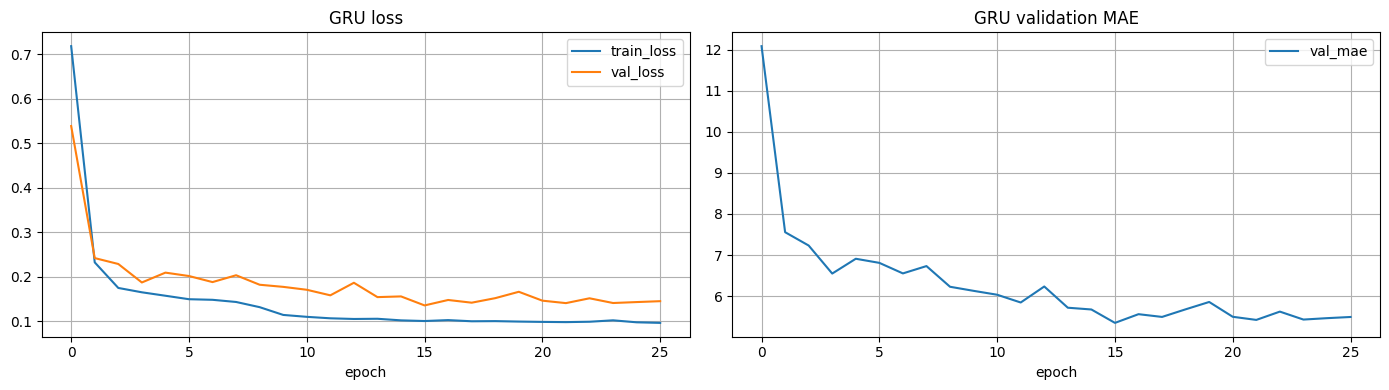

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(gru_history["train_loss"], label="train_loss")
axes[0].plot(gru_history["val_loss"], label="val_loss")
axes[0].set_title("GRU loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(gru_history["val_mae"], label="val_mae")
axes[1].set_title("GRU validation MAE")
axes[1].set_xlabel("epoch")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "gru_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Сравнение всех экспериментов

In [18]:
gru_val_true, gru_val_pred = predict_sequence_split(gru_model, val_loader, target_scaler, DEVICE)
gru_test_true, gru_test_pred = predict_sequence_split(gru_model, test_loader, target_scaler, DEVICE)

gru_val_metrics = regression_metrics(gru_val_true, gru_val_pred)
gru_test_metrics = regression_metrics(gru_test_true, gru_test_pred)

runs = [
    {
        "experiment_id": "B1",
        "task": "forecasting",
        "dataset": DATA_PATH.name,
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": "",
        "horizon": 1,
        "model_summary": "naive last value",
        "features_summary": "lag_1",
        "scaler": "None",
        "optimizer": "None",
        "lr": "",
        "epochs_trained": "",
        "best_val_mae": b1_val_metrics["mae"],
        "best_val_rmse": b1_val_metrics["rmse"],
        "best_val_mape": b1_val_metrics["mape"],
        "test_mae": b1_test_metrics["mae"],
        "test_rmse": b1_test_metrics["rmse"],
        "test_mape": b1_test_metrics["mape"],
        "notes": "baseline using previous observed value",
    },
    {
        "experiment_id": "B2",
        "task": "forecasting",
        "dataset": DATA_PATH.name,
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": "",
        "horizon": 1,
        "model_summary": "moving average baseline",
        "features_summary": "rolling_mean_7",
        "scaler": "None",
        "optimizer": "None",
        "lr": "",
        "epochs_trained": "",
        "best_val_mae": b2_val_metrics["mae"],
        "best_val_rmse": b2_val_metrics["rmse"],
        "best_val_mape": b2_val_metrics["mape"],
        "test_mae": b2_test_metrics["mae"],
        "test_rmse": b2_test_metrics["rmse"],
        "test_mape": b2_test_metrics["mape"],
        "notes": "baseline using 7-day mean of past target values",
    },
    {
        "experiment_id": "B3",
        "task": "forecasting",
        "dataset": DATA_PATH.name,
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": "",
        "horizon": 1,
        "model_summary": "Ridge regression",
        "features_summary": ", ".join(feature_cols),
        "scaler": "StandardScaler(features)",
        "optimizer": "Ridge",
        "lr": "",
        "epochs_trained": 1,
        "best_val_mae": b3_val_metrics["mae"],
        "best_val_rmse": b3_val_metrics["rmse"],
        "best_val_mape": b3_val_metrics["mape"],
        "test_mae": b3_test_metrics["mae"],
        "test_rmse": b3_test_metrics["rmse"],
        "test_mape": b3_test_metrics["mape"],
        "notes": "fit on train only; features have no future leakage",
    },
    {
        "experiment_id": "R1",
        "task": "forecasting",
        "dataset": DATA_PATH.name,
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": WINDOW_SIZE,
        "horizon": 1,
        "model_summary": f"GRU(input_size=1, hidden_size={GRU_CONFIG['hidden_size']}, layers={GRU_CONFIG['num_layers']})",
        "features_summary": "windowed target sequence",
        "scaler": "StandardScaler(target)",
        "optimizer": "Adam",
        "lr": GRU_CONFIG["lr"],
        "epochs_trained": len(gru_history["train_loss"]),
        "best_val_mae": gru_val_metrics["mae"],
        "best_val_rmse": gru_val_metrics["rmse"],
        "best_val_mape": gru_val_metrics["mape"],
        "test_mae": gru_test_metrics["mae"],
        "test_rmse": gru_test_metrics["rmse"],
        "test_mape": gru_test_metrics["mape"],
        "notes": f"best epoch={gru_best_payload['epoch']}; early stopping on val MAE",
    },
]

runs_df = pd.DataFrame(runs).sort_values("best_val_mae").reset_index(drop=True)
display(runs_df)

runs_df.to_csv(ARTIFACTS_DIR / "runs.csv", index=False)
print("Saved:", ARTIFACTS_DIR / "runs.csv")

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,R1,forecasting,S12-hw-dataset.csv,42,"train=3014 rows (2025-01-01..2025-05-07), val=...",28,1,"GRU(input_size=1, hidden_size=64, layers=1)",windowed target sequence,StandardScaler(target),Adam,0.001,26,5.346086,6.912483,3.606912,6.042394,7.735295,3.896787,best epoch=16; early stopping on val MAE
1,B1,forecasting,S12-hw-dataset.csv,42,"train=3014 rows (2025-01-01..2025-05-07), val=...",,1,naive last value,lag_1,None,None,,,6.443406,8.203532,4.394594,6.338019,8.059906,4.143508,baseline using previous observed value
2,B3,forecasting,S12-hw-dataset.csv,42,"train=3014 rows (2025-01-01..2025-05-07), val=...",,1,Ridge regression,"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler(features),Ridge,,1,7.171741,8.723752,4.782421,7.318698,9.028900,4.685315,fit on train only; features have no future lea...
3,B2,forecasting,S12-hw-dataset.csv,42,"train=3014 rows (2025-01-01..2025-05-07), val=...",,1,moving average baseline,rolling_mean_7,None,None,,,12.723717,15.236326,8.828779,12.725250,15.226179,8.534403,baseline using 7-day mean of past target values


Saved: artifacts/runs.csv


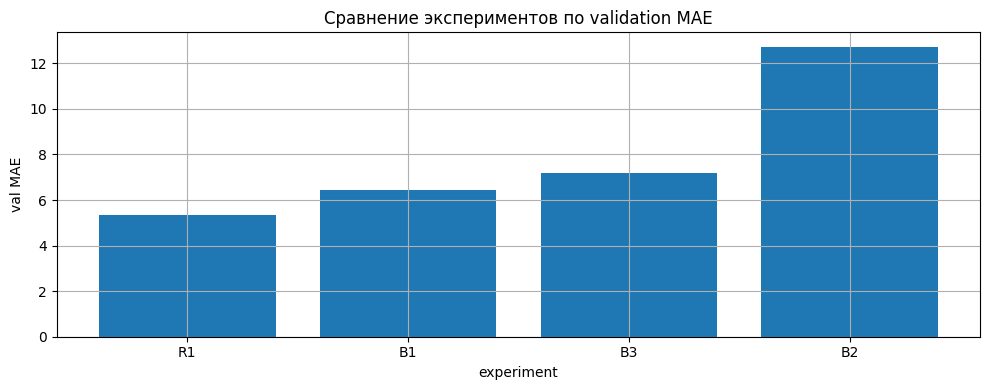

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(runs_df["experiment_id"], runs_df["best_val_mae"])
ax.set_title("Сравнение экспериментов по validation MAE")
ax.set_xlabel("experiment")
ax.set_ylabel("val MAE")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "baselines_compare.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Финальный выбор лучшего подхода и test-оценка

In [20]:
best_row = runs_df.iloc[0]
best_experiment_id = best_row["experiment_id"]
print("Best experiment by validation MAE:", best_experiment_id)
display(best_row.to_frame().T)

Best experiment by validation MAE: R1


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,R1,forecasting,S12-hw-dataset.csv,42,"train=3014 rows (2025-01-01..2025-05-07), val=...",28,1,"GRU(input_size=1, hidden_size=64, layers=1)",windowed target sequence,StandardScaler(target),Adam,0.001,26,5.346086,6.912483,3.606912,6.042394,7.735295,3.896787,best epoch=16; early stopping on val MAE


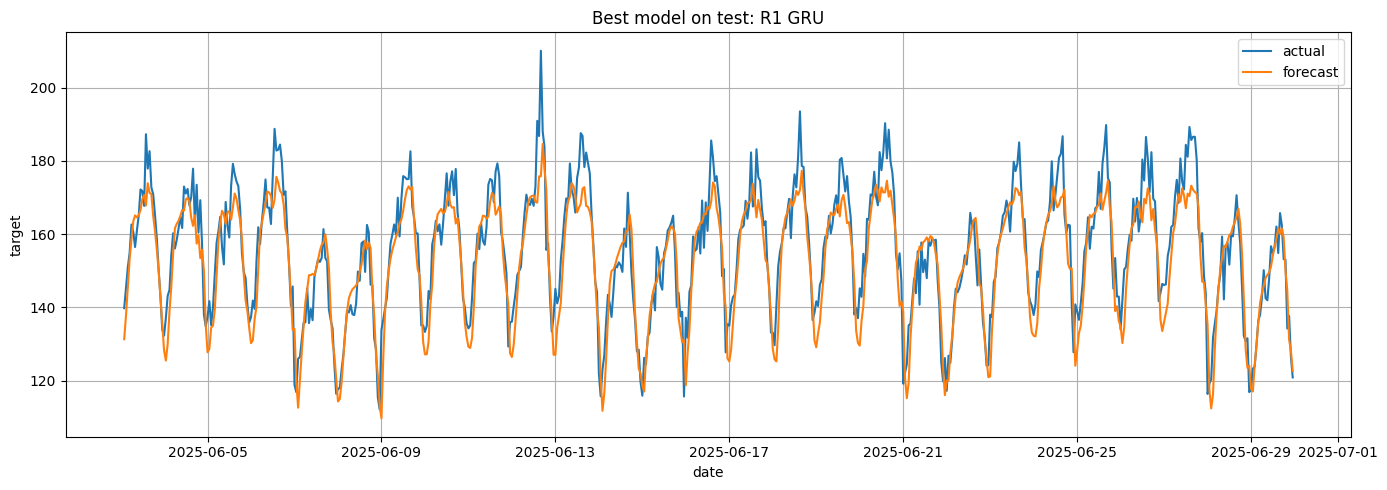

Best test metrics: {'mae': 6.042393684387207, 'rmse': 7.735294541691901, 'mape': np.float32(3.8967867), 'smape': np.float32(3.9561417)}


In [21]:
def plot_best_test_forecast():
    if best_experiment_id == "B1":
        dates = test_df["date"].to_numpy()
        y_true = test_df["target"].to_numpy()
        y_pred = b1_test_pred
        title = "Best model on test: B1 naive-last"
    elif best_experiment_id == "B2":
        dates = test_df["date"].to_numpy()
        y_true = test_df["target"].to_numpy()
        y_pred = b2_test_pred
        title = "Best model on test: B2 moving-average"
    elif best_experiment_id == "B3":
        dates = test_df["date"].to_numpy()
        y_true = y_test.to_numpy()
        y_pred = b3_test_pred
        title = "Best model on test: B3 Ridge"
    else:
        dates = test_df["date"].to_numpy()
        y_true = gru_test_true
        y_pred = gru_test_pred
        title = "Best model on test: R1 GRU"

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates, y_true, label="actual", linewidth=1.5)
    ax.plot(dates, y_pred, label="forecast", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("date")
    ax.set_ylabel("target")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "best_forecast_test.png", dpi=150, bbox_inches="tight")
    plt.show()

    return regression_metrics(y_true, y_pred)


best_test_metrics = plot_best_test_forecast()
print("Best test metrics:", best_test_metrics)

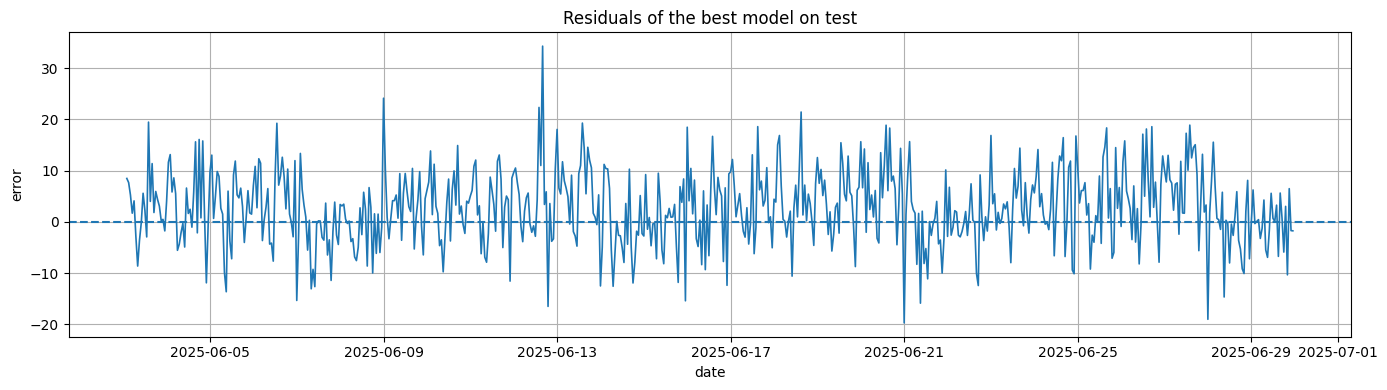

In [22]:
# Дополнительная проверка ошибок на тесте для лучшего эксперимента
if best_experiment_id == "R1":
    residuals = gru_test_true - gru_test_pred
    residual_dates = test_df["date"].to_numpy()
elif best_experiment_id == "B3":
    residuals = y_test.to_numpy() - b3_test_pred
    residual_dates = test_df["date"].to_numpy()
elif best_experiment_id == "B2":
    residuals = test_df["target"].to_numpy() - b2_test_pred
    residual_dates = test_df["date"].to_numpy()
else:
    residuals = test_df["target"].to_numpy() - b1_test_pred
    residual_dates = test_df["date"].to_numpy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(residual_dates, residuals, linewidth=1.2)
ax.axhline(0.0, linestyle="--")
ax.set_title("Residuals of the best model on test")
ax.set_xlabel("date")
ax.set_ylabel("error")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "residuals_best.png", dpi=150, bbox_inches="tight")
plt.show()